## Problem Statement
The objective of this analysis is to:
1. Examine demographic and clinical characteristics of eye cancer patients.
2. Predict patient outcome status using supervised machine learning.
3. Estimate survival probabilities and hazard ratios using survival analysis.

In [308]:
import warnings
import pandas as pd
import seaborn as sns
import shap
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from lifelines import KaplanMeierFitter, CoxPHFitter
from fastapi import FastAPI 
import streamlit as st
import requests
warnings.filterwarnings("ignore")

In [309]:
def wrangle( filepath):
    df=pd.read_csv(filepath)
    df.drop(columns=["Patient_ID"],inplace=True)
    df["Date_of_Diagnosis"] = pd.to_datetime(df["Date_of_Diagnosis"])
    df["Diagnosis_Year"] = df["Date_of_Diagnosis"].dt.year
    df["Stage_Ordinal"] = df["Stage_at_Diagnosis"].replace ({"Stage I":1,"Stage II":2,"Stage III":3,"Stage IV":4})
    df["Late_Stage"] = df["Stage_at_Diagnosis"].isin(["Stage III", "Stage IV"]).astype(int)
    df["Elderly"] = (df["Age"] >= 65).astype(int)
    df["Genetic_Markers"] = df["Genetic_Markers"].fillna("Not Tested / Negative")
    return df

In [310]:
df=wrangle("C:/Users/musyo/Downloads/Datasets-20240315/eye_cancer_patients.csv")
print(f"df shape;{df.shape}")
df.head()

df shape;(5000, 19)


,Age,Gender,Cancer_Type,Laterality,Date_of_Diagnosis,Stage_at_Diagnosis,Treatment_Type,Surgery_Status,Radiation_Therapy,Chemotherapy,Outcome_Status,Survival_Time_Months,Genetic_Markers,Family_History,Country,Diagnosis_Year,Stage_Ordinal,Late_Stage,Elderly
0,58,F,Retinoblastoma,Left,2019-01-25,Stage IV,Radiation,False,15,3,Deceased,85,Not Tested / Negative,True,UK,2019,4,1,0
1,15,Other,Retinoblastoma,Right,2021-10-21,Stage III,Chemotherapy,True,69,6,In Remission,10,Not Tested / Negative,True,Japan,2021,3,1,0
2,64,M,Retinoblastoma,Bilateral,2021-03-12,Stage IV,Surgery,False,47,6,In Remission,3,BRAF Mutation,False,UK,2021,4,1,0
3,33,M,Melanoma,Right,2021-05-10,Stage II,Radiation,True,36,6,Active,40,Not Tested / Negative,False,Canada,2021,2,0,0
4,8,Other,Lymphoma,Left,2019-11-24,Stage I,Chemotherapy,False,14,14,In Remission,26,BRAF Mutation,True,USA,2019,1,0,0


In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Age                   5000 non-null   int64         
 1   Gender                5000 non-null   object        
 2   Cancer_Type           5000 non-null   object        
 3   Laterality            5000 non-null   object        
 4   Date_of_Diagnosis     5000 non-null   datetime64[ns]
 5   Stage_at_Diagnosis    5000 non-null   object        
 6   Treatment_Type        5000 non-null   object        
 7   Surgery_Status        5000 non-null   bool          
 8   Radiation_Therapy     5000 non-null   int64         
 9   Chemotherapy          5000 non-null   int64         
 10  Outcome_Status        5000 non-null   object        
 11  Survival_Time_Months  5000 non-null   int64         
 12  Genetic_Markers       5000 non-null   object        
 13  Family_History    

In [261]:
df.describe(include="all")

,Age,Gender,Cancer_Type,Laterality,Date_of_Diagnosis,Stage_at_Diagnosis,Treatment_Type,Surgery_Status,Radiation_Therapy,Chemotherapy,Outcome_Status,Survival_Time_Months,Genetic_Markers,Family_History,Country,Diagnosis_Year,Stage_Ordinal,Late_Stage,Elderly
count,5000.000000,5000,5000,5000,5000,5000,5000,5000,5000.000000,5000.000000,5000,5000.000000,5000,5000,5000,5000.00000,5000.000000,5000.000000,5000.000000
unique,NaN,3,3,3,NaN,4,3,2,NaN,NaN,3,NaN,2,2,10,NaN,NaN,NaN,NaN
top,NaN,Other,Melanoma,Bilateral,NaN,Stage II,Surgery,True,NaN,NaN,Deceased,NaN,BRAF Mutation,False,South Africa,NaN,NaN,NaN,NaN
freq,NaN,1720,1691,1695,NaN,1287,1679,2550,NaN,NaN,1710,NaN,2503,2538,544,NaN,NaN,NaN,NaN
mean,45.008000,NaN,NaN,NaN,2022-01-11 22:00:11.520000,NaN,NaN,NaN,35.447600,10.057400,NaN,60.716000,NaN,NaN,NaN,2021.52460,2.515000,0.504600,0.286400
min,1.000000,NaN,NaN,NaN,2019-01-02 00:00:00,NaN,NaN,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,NaN,2019.00000,1.000000,0.000000,0.000000
25%,22.000000,NaN,NaN,NaN,2020-07-08 18:00:00,NaN,NaN,NaN,18.000000,5.000000,NaN,31.000000,NaN,NaN,NaN,2020.00000,2.000000,0.000000,0.000000
50%,44.000000,NaN,NaN,NaN,2022-01-15 00:00:00,NaN,NaN,NaN,35.000000,10.000000,NaN,60.000000,NaN,NaN,NaN,2022.00000,3.000000,1.000000,0.000000
75%,67.000000,NaN,NaN,NaN,2023-07-20 00:00:00,NaN,NaN,NaN,53.000000,15.000000,NaN,90.000000,NaN,NaN,NaN,2023.00000,3.000000,1.000000,1.000000
max,90.000000,NaN,NaN,NaN,2024-12-30 00:00:00,NaN,NaN,NaN,70.000000,20.000000,NaN,120.000000,NaN,NaN,NaN,2024.00000,4.000000,1.000000,1.000000


In [262]:
df["Outcome_Status"].value_counts(normalize=True)

Outcome_Status
Deceased        0.342
In Remission    0.335
Active          0.323
Name: proportion, dtype: float64

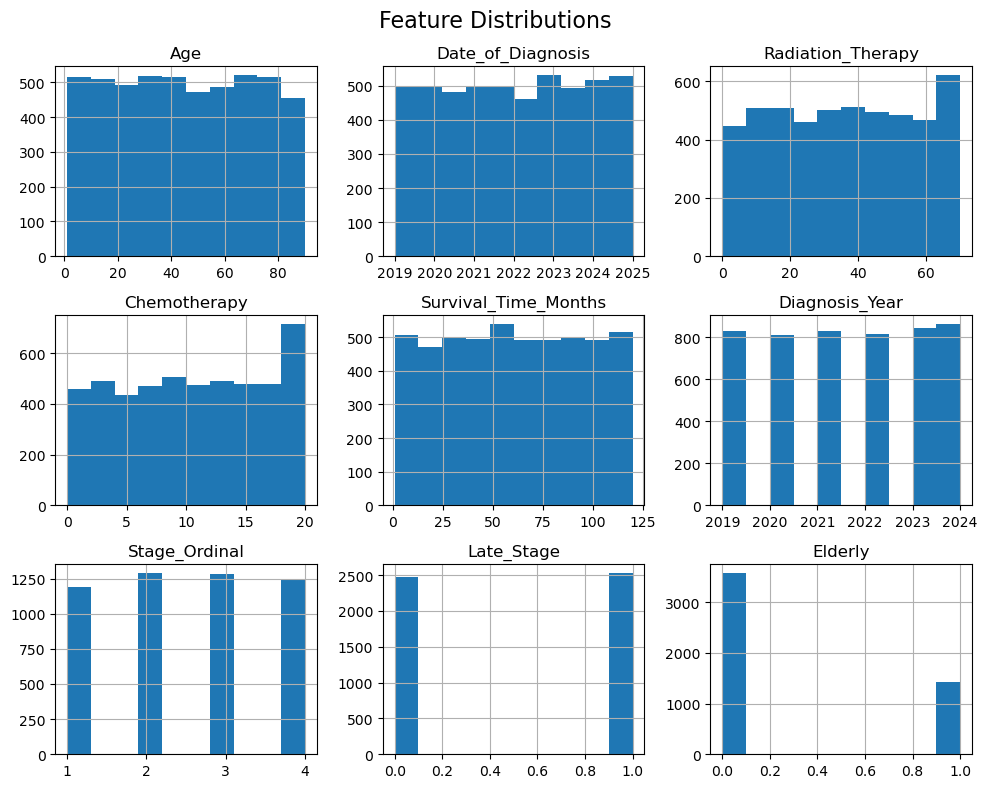

In [263]:
df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout();

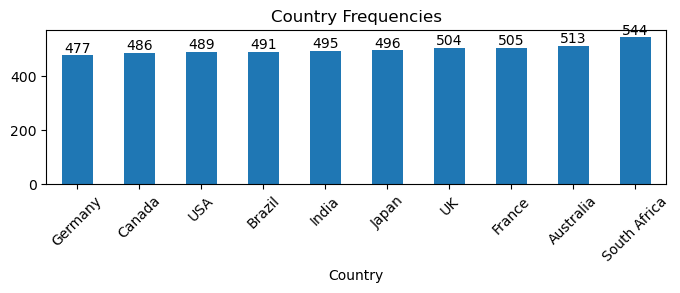

In [264]:
fig,ax=plt.subplots(figsize=(8,2))
df["Country"].value_counts().sort_values().plot(kind="bar",ax=ax)
for container in ax.containers:
    ax.bar_label(container,fmt="%.f")
plt.xticks(rotation=45)
plt.title("Country Frequencies")
plt.show()

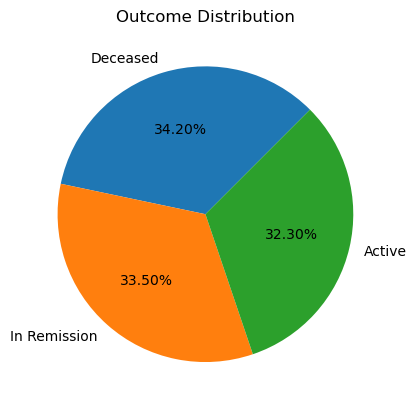

In [171]:
df["Outcome_Status"].value_counts(normalize=True).plot(kind="pie",autopct="%1.2f%%",startangle=45)
plt.title("Outcome Distribution")
plt.ylabel("");

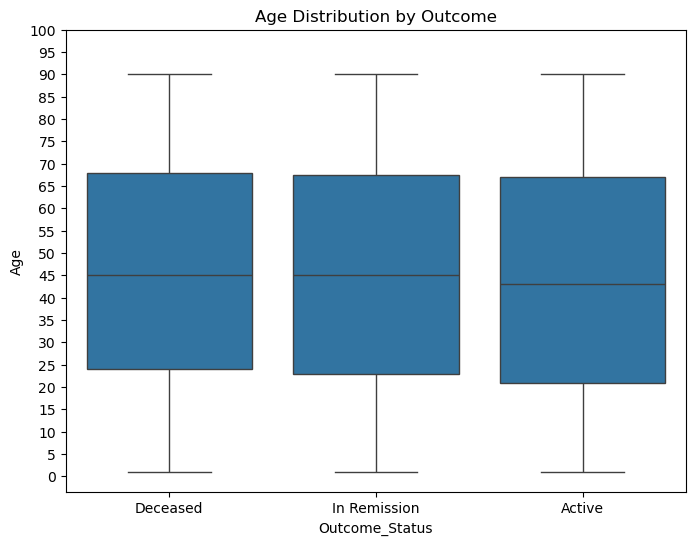

In [173]:
fig,ax=plt.subplots(figsize=(8,6))
sns.boxplot(df,x="Outcome_Status",y="Age",ax=ax)
plt.yticks(range(0,105,5))
ax.set_title("Age Distribution by Outcome");

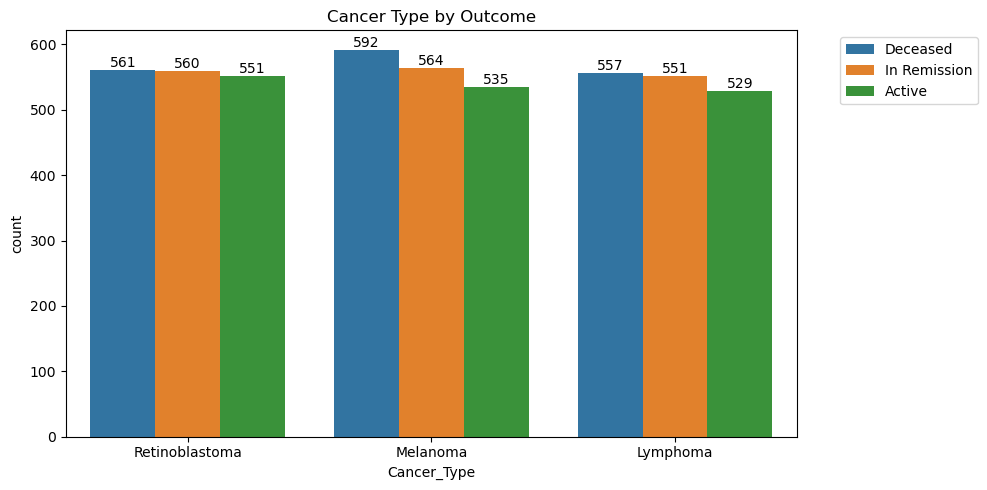

In [180]:
fig,ax=plt.subplots(figsize=(10,5))
sns.countplot(data=df,x="Cancer_Type",hue="Outcome_Status",ax=ax)

for container in ax.containers:
        ax.bar_label(container,fmt="%.f")
ax.set_title("Cancer Type by Outcome")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout();

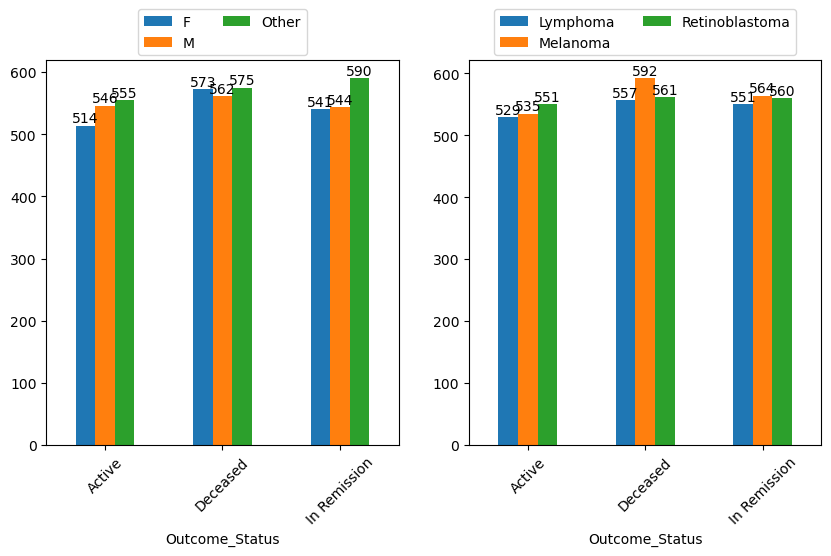

In [34]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
df.groupby(["Outcome_Status","Gender"]).size().unstack().plot(kind="bar",ax=ax[0])
df.groupby(["Outcome_Status","Cancer_Type"]).size().unstack().plot(kind="bar",ax=ax[1])
for a in ax:
    a.tick_params(axis='x', rotation=45)
for a in ax:
    for container in a.containers:
        a.bar_label(container,fmt="%.f")
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2);

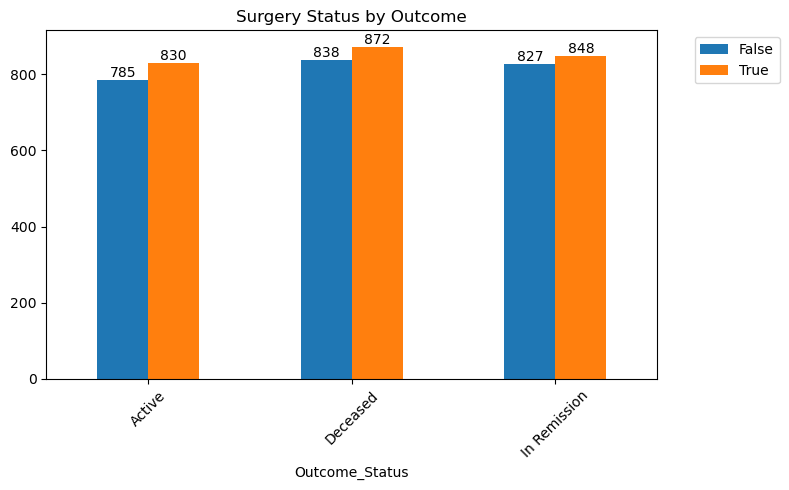

In [187]:
fig,ax=plt.subplots(figsize=(8, 5))
df.groupby(["Outcome_Status","Surgery_Status"]).size().unstack().plot(kind="bar",ax=ax)
for container in ax.containers:
    ax.bar_label(container,fmt="%.f")
plt.xticks(rotation=45)
ax.set_title("Surgery Status by Outcome")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout();

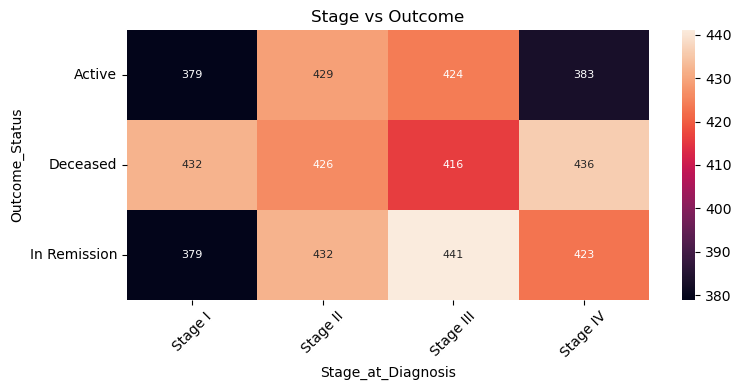

In [189]:
plt.figure(figsize=(8, 4)) 
CT=df.groupby(["Outcome_Status","Stage_at_Diagnosis"]).size().unstack()
sns.heatmap(CT,annot=True,fmt="d",annot_kws={"size": 8})
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Stage vs Outcome")
plt.tight_layout()
plt.show()

In [266]:
le = LabelEncoder()
y =le.fit_transform(df["Outcome_Status"])
X = df.drop(columns=["Outcome_Status","Date_of_Diagnosis","Stage_at_Diagnosis"])

categorical_features = X.select_dtypes(include=["object","bool"]).columns
numerical_features = X.select_dtypes(exclude=["object","bool"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",drop="first"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.25,stratify=y,random_state=42)
print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")

Train : 3,750 rows
Test  : 1,250 rows


In [267]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)
print(classification_report(y_test, baseline_preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       404
           1       0.34      1.00      0.51       427
           2       0.00      0.00      0.00       419

    accuracy                           0.34      1250
   macro avg       0.11      0.33      0.17      1250
weighted avg       0.12      0.34      0.17      1250



In [268]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,max_depth=5,learning_rate= 0.05,
        subsample=0.8,colsample_bytree= 0.8,
        objective="multi:softprob",eval_metric="mlogloss",
        random_state=42  
    ),
    "lightgbm ": LGBMClassifier(
        n_estimators=300,num_leaves=31,learning_rate=0.05,
        objective="multiclass",random_state=42,verbose=-1
    ),
    "RandomForestClassifier": RandomForestClassifier(
         n_estimators=300,max_depth=8,
         class_weight="balanced",random_state=42
    ),
    "Logistic Regression":LogisticRegression(max_iter=1000,solver="lbfgs")
}

In [313]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
best_score = -np.inf
best_pipeline = None

for name, model in models.items():
    pipe = Pipeline([
         ("preprocessor", preprocessor),
         ("classifier", model)
     ])
    
    cv_f1 = cross_val_score(pipe,X_train,y_train,cv=cv,
        scoring="f1_macro"
    ).mean()

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    test_f1 = classification_report(y_test, y_pred, output_dict=True,zero_division=0)["macro avg"]["f1-score"]
    results.append({
        "model":name,
        "cv_f1_mean": cv_f1,
        "test_f1": test_f1,
       "pipeline": pipe
    })

    if test_f1 > best_score:
        best_score = test_f1
        best_pipeline = pipe
        best_name = name

#Print summary
print("=" * 60)
print("MODEL EVALUATION SUMMARY")
print("=" * 60)
for res in results:
    print(f"{res['model']:20s} | CV F1: {res['cv_f1_mean']:.4f} | Test F1: {res['test_f1']:.4f}")
        
print(f"\nBest model: {best_pipeline.named_steps['classifier'].__class__.__name__}")
print("="*50)   

MODEL EVALUATION SUMMARY
XGBoost              | CV F1: 0.3207 | Test F1: 0.3601
lightgbm             | CV F1: 0.3271 | Test F1: 0.3349
RandomForestClassifier | CV F1: 0.3351 | Test F1: 0.3344
Logistic Regression  | CV F1: 0.3134 | Test F1: 0.3112

Best model: XGBClassifier


In [317]:
model = best_pipeline.named_steps["classifier"]
preprocessor = best_pipeline.named_steps["preprocessor"]

X_train_trans = preprocessor.transform(X_train)
feature_names = preprocessor.get_feature_names_out()
explainer = shap.Explainer(model, X_train_trans)
shap_values = explainer(X_train_trans)

Background dataset has 3750 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3750 when initializing the masker.
100%|===================| 11248/11250 [08:19<00:00]        

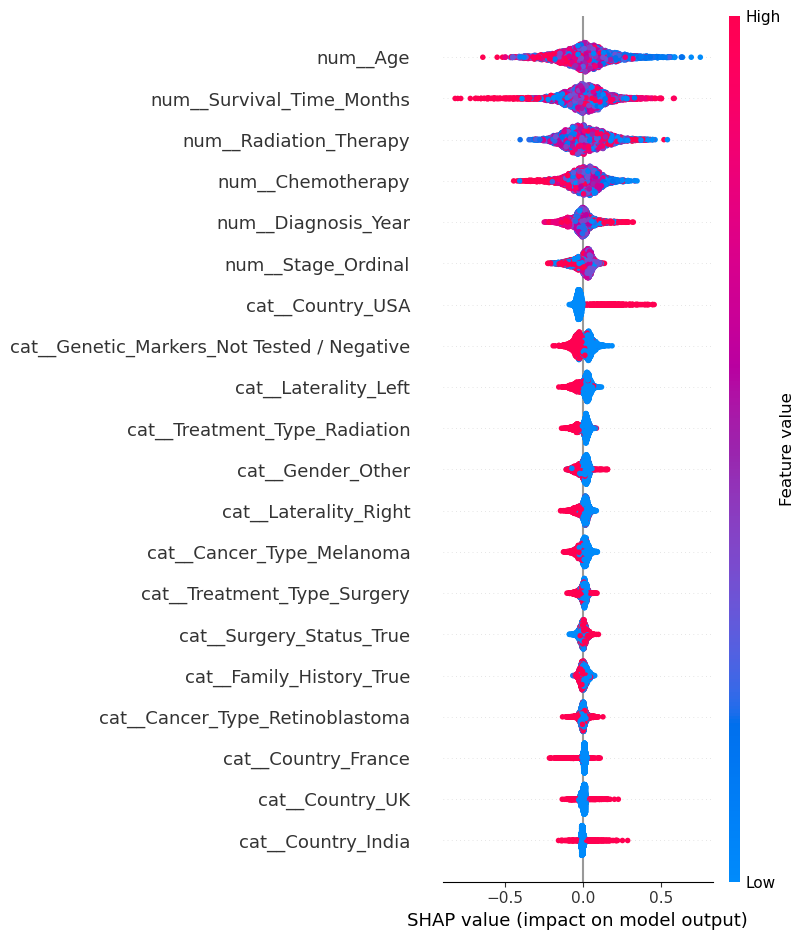

In [323]:
shap.summary_plot(
    shap_values.values[:, :, 0],
    X_train_trans,
    feature_names=feature_names,
    show=True
)

In [314]:
# Evaluate best model on test set with detailed report
print("\n" + "-"*40)
print("BEST MODEL CLASSIFICATION REPORT")
print("-"*40)
y_pred_best = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=class_names))


----------------------------------------
BEST MODEL CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

      Active       0.38      0.35      0.36       404
    Deceased       0.35      0.36      0.35       427
In Remission       0.35      0.37      0.36       419

    accuracy                           0.36      1250
   macro avg       0.36      0.36      0.36      1250
weighted avg       0.36      0.36      0.36      1250



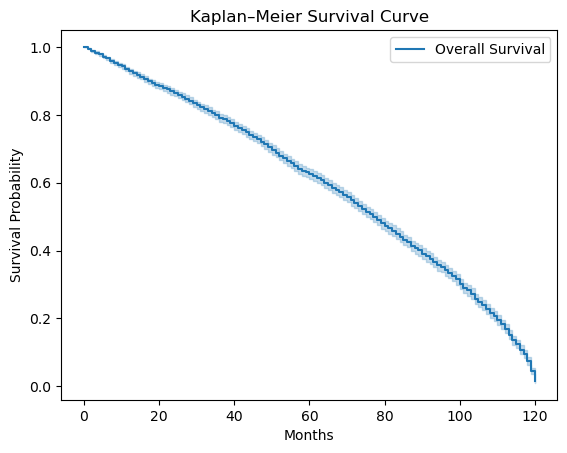

In [329]:
survival_df = df[
    ["Survival_Time_Months", "Outcome_Status", "Age", "Late_Stage", "Elderly"]
].dropna()
kmf = KaplanMeierFitter()
kmf.fit(
    durations=survival_df["Survival_Time_Months"],
    event_observed=y, 
    label="Overall Survival"
)

kmf.plot_survival_function()
plt.title("Kaplan–Meier Survival Curve")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()

In [328]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(
    survival_df,
    duration_col="Survival_Time_Months",
    event_col="Outcome_Status",
    robust=True
)
cph.print_summary()

model,lifelines.CoxPHFitter
duration col,'Survival_Time_Months'
event col,'Outcome_Status'
penalizer,0.1
l1 ratio,0.0
robust variance,True
baseline estimation,breslow
number of observations,5000
number of events observed,3385
partial log-likelihood,-25468.83
time fit was run,2026-06-22 09:59:03 UTC
